## Using harmony-py for subsetting/reformatting NASA Earthdata

### What is Harmony?

Data reduction services allow users to request only the data they want, in the format and projection they want

*specific transformation services are enabled for data sets on a priority basis - Harmony is a WIP*

Reference: https://harmony.earthdata.nasa.gov/

### What is harmony-py?

Harmony-Py provides a Python alternative to directly using Harmony’s RESTful API. It handles NASA Earthdata Login (EDL) authentication and optionally integrates with the CMR Python Wrapper by accepting collection results as a request parameter.

Reference: https://harmony-py.readthedocs.io/



#### Overview of today's tutorial

1. Import packages
2. Authenticate with EDL and initialize a Harmony client
3. Define and explore a dataset
4. Build a request
5. Request, Download and plot your data!

#### Requirements

Earthdata Login

python 3.9 or higher

installation of `harmony-py`

Other python packages: `datetime` , `rasterio` for plotting data and `json` for displaying information
    

### Background: installing harmony-py

I have already added harmony-py to my environment, but you should be sure you do as well or manually install the package:

`pip install -U harmony-py`

### 1. Import Packages

In [ ]:
pip install -U harmony-py earthaccess rasterio


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.1/77.1 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.6/37.6 MB 88.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 203.4/203.4 kB 22.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 148.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.5/89.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 15.0/15.0 MB 128.6 MB/s eta 0:00:00
  Created wheel for curlify: filename=curlify-2.2.1-py3-none-any.whl size=2743 sha256=9daec27dee93da667ce95e4da4ae91c4724d3e2f26d12c71701b55d9fac779eb
  Stored in directory: /root/.cache/pip/wheels/de/b1/32/218427ea0fc33dda6ec9259a8dbc440c6a04bd2f37c1d67a68
Successfully built curlify
  Attempting uninstall: python-dotenv
    Found existing installation: python-dotenv 1.2.2
    Uninstalli

In [ ]:
# Hiding my password as I type!
import getpass
import earthaccess
# Help for reading a JSON output in readable form
import json
from IPython.display import display, JSON

# Working with the data
import datetime as dt
import rasterio
import rasterio.plot

from harmony import BBox, Client, Collection, Request, CapabilitiesRequest

### 2. Authentication and Harmony client initialization

In [ ]:
EDL_username = input('EDL username?:')
EDL_password = getpass.getpass('EDL password?:')
harmony_client = Client(auth=(EDL_username, EDL_password))

EDL username?:anneliesq
EDL password?:··········


### 3. Dataset selection and services discovery

#### Define dataset

Define which data set you’d like to access using either the dataset short name or its collection concept-id (see [how-to](https://nsidc.github.io/NSIDC-Data-Cookbook/how-to-guides/get_concept-ids.html) for retrieving collection concept-ids). For this example, we’ll use SMAP L3 Radiometer Global Daily 36 km EASE-Grid Soil Moisture, Version 9 (SPL3SMP), C2938664585-NSIDC_CPRD.

In [ ]:
results = earthaccess.search_datasets(
    keyword = 'TEMPO NO2 L2',
    cloud_hosted = True
)

In [ ]:
for r in results[:10]:
    print(', '.join([r.summary()[key] for key in ["short-name", "version", "concept-id"]]))

TEMPO_NO2_L2, V04, C3685896872-LARC_CLOUD
TEMPO_NO2_L2_NRT, V02, C3685668972-LARC_CLOUD
TEMPO_NO2_L3, V03, C2930763263-LARC_CLOUD
TEMPO_NO2_L2, V03, C2930725014-LARC_CLOUD


/tmp/ipykernel_1193/1639572260.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  print(', '.join([r.summary()[key] for key in ["short-name", "version", "concept-id"]]))
/tmp/ipykernel_1193/1639572260.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  print(', '.join([r.summary()[key] for key in ["short-name", "version", "concept-id"]]))
/tmp/ipykernel_1193/1639572260.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g. use `DataCollection.summary` **not** `DataCollection.summary()`
  print(', '.join([r.summary()[key] for key in ["short-name", "version", "concept-id"]]))
/tmp/ipykernel_1193/1639572260.py:2: FutureWarning: As of version 1.0, `DataCollection.summary` will be accessed as an attribute; e.g

In [ ]:
dataset_short_name = 'TEMPO_NO2_L2'
dataset_collection_id = 'C2930725014-LARC_CLOUD'

#### Discover subsetting capabilities

Harmony has different subsetting services depending on the data set of interest

In [ ]:
capabilities_request = CapabilitiesRequest(collection_id=dataset_collection_id)

In [ ]:
capabilities = harmony_client.submit(capabilities_request)

In [ ]:
JSON(capabilities)

<IPython.core.display.JSON object>

### 4. Build a Request

Based on what is returned in the capabilities request JSON string for our data set, we can ask for particular subsetting!

In the request below, we'll set our collection to SPL3SMP which has services for spatial, temporal and variable subsetting as well as reformatting options.

In [ ]:
from calendar import monthrange

for month in range(1, 13):
    last_day = monthrange(2024, month)[1]
    request = Request(
        collection=Collection(id='C2930725014-LARC_CLOUD'),
        spatial=BBox(-107.5, 44.5, -105.5, 47.5),
        temporal={
            'start': dt.datetime(2024, month, 1),
            'stop': dt.datetime(2024, month, last_day, 23, 59, 59)
        },
        variables=['geolocation/solar_zenith_angle',
                   'support_data/scattering_weights',
                   'mirror_step',
                   'xtrack',
                   'support_data/surface_pressure',
                   'support_data/amf_troposphere',
                   'support_data/tropopause_pressure',
                   'support_data/eff_cloud_fraction',
                   'product/main_data_quality_flag',
                   'product/vertical_column_troposphere',
                   'geolocation/latitude',
                   'geolocation/longitude',
                   'geolocation/time',
                   ],
        format='application/netcdf',
        concatenate=True
    )
    job_id = harmony_client.submit(request)
    print(f'Month {month}: submitted {job_id}')

    harmony_client.session.post(
        f'https://harmony.earthdata.nasa.gov/jobs/{job_id}/skip-preview'
    )
    print(f'Month {month}: preview skipped')

    harmony_client.wait_for_processing(job_id, show_progress=True)

    futures = harmony_client.download_all(job_id, directory='/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2')
    filelist = [f.result() for f in futures]
    for f in filelist:
        new_name = f'/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/Colstrip_TEMPO_L2_month_{dt.datetime(2024, month, 1).strftime("%Y%m%d")}_{dt.datetime(2024, month, last_day).strftime("%Y%m%d")}_merged.nc4'
        os.rename(f, new_name)
        print(f'Month {month}: saved as {new_name}')

Month 1: submitted 3f325ae4-aa9a-4a12-8419-4f129470e1da
Month 1: preview skipped


 [ Processing: 100% ] |###################################################| [|]


/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/225978693_C2930725014-LARC_CLOUD_batch_of_1_starting_from_TEMPO_NO2_L2_V03_20240101T132506Z_S001G06_subsetted_stitched_20240123T232036Z_C2930725014-LARC_CLOUD_merged.nc4
Month 1: saved as /content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/Colstrip_TEMPO_L2_month_20240101_20240131_merged.nc4
Month 2: submitted 063a991b-8ce2-4cdf-b806-60b189eaa238
Month 2: preview skipped


 [ Processing: 100% ] |###################################################| [|]


/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/225980600_C2930725014-LARC_CLOUD_batch_of_1_starting_from_TEMPO_NO2_L2_V03_20240201T133524Z_S002G06_subsetted_stitched_20240229T232124Z_C2930725014-LARC_CLOUD_merged.nc4
Month 2: saved as /content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/Colstrip_TEMPO_L2_month_20240201_20240229_merged.nc4
Month 3: submitted 36f7a88f-33ca-4604-822c-7f0f20188b50
Month 3: preview skipped


...

/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/226024204_C2930725014-LARC_CLOUD_batch_of_2_starting_from_TEMPO_NO2_L2_V03_20241001T000142Z_S016G03_subsetted_stitched_20241031T230208Z_C2930725014-LARC_CLOUD_merged.nc4
Month 10: saved as /content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/Colstrip_TEMPO_L2_month_20241001_20241031_merged.nc4
Month 11: submitted 3a421ea3-f870-4874-841e-de59d12bdc60
Month 11: preview skipped


 [ Processing: 100% ] |###################################################| [|]


/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/226025719_C2930725014-LARC_CLOUD_batch_of_1_starting_from_TEMPO_NO2_L2_V03_20241101T125455Z_S002G06_subsetted_stitched_20241130T231358Z_C2930725014-LARC_CLOUD_merged.nc4
Month 11: saved as /content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/Colstrip_TEMPO_L2_month_20241101_20241130_merged.nc4
Month 12: submitted 680a68af-3f24-4736-aa8a-020bb13e0d27
Month 12: preview skipped


 [ Processing: 100% ] |###################################################| [|]


/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/226038664_C2930725014-LARC_CLOUD_batch_of_1_starting_from_TEMPO_NO2_L2_V03_20241201T130616Z_S002G06_subsetted_stitched_20241231T220719Z_C2930725014-LARC_CLOUD_merged.nc4
Month 12: saved as /content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/Colstrip_TEMPO_L2_month_20241201_20241231_merged.nc4


### 5. Request, download and plot your data!

#### Submit the Request

In [ ]:
job_id = harmony_client.submit(request)

The job_id can be used to check on the details of your job progress. If you are logged into Earthdata, you can see your jobs here: https://harmony.earthdata.nasa.gov/workflow-ui

View the URLs for your staged data

In [ ]:
url = list(results)
url

['https://harmony.earthdata.nasa.gov/service-results/harmony-prod-staging/public/ee2ae92f-1719-4fe9-a192-c869ed51f688/225727758/C2930725014-LARC_CLOUD_batch_of_1_starting_from_TEMPO_NO2_L2_V03_20240201T133524Z_S002G06_subsetted_stitched_20240229T232124Z_C2930725014-LARC_CLOUD_merged.nc4']

#### Download results to your local directory

#### Plot your results!

#### Pull TEMPO for AERMOD

In [ ]:
!pip install xarray utm netCDF4

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 73.9 MB/s eta 0:00:00


In [ ]:
#!/home/harkey/miniconda3/envs/plotenv/bin/python

import os
import gc
import pandas as pd
import xarray as xr
import numpy as np
from datetime import datetime, timedelta
import glob
import utm

# this script will read in an AERMOD output file and pull TEMPO data for the same domain for the time period specified.
# output will be a csv file for ease of read with pandas in next step (calc_AERMOD_col.py)

# Need to convert x,y to lat lon from UTM: output file has x,y for each receptor; the aermap file has the UTM zone with the stack origin, for example
# ** ANCHORXY 244502.214 3263734.935 244502.214 3263734.935 15 0  --here the UTM zone is 15
origin_zone = 13
# outfile is assumed to be in format of maxifile with hourly output
#OUTfile = '/home/harkey/AERMOD/ColstripMT/AERMOD/ColstripMT-NWS_2024_hourlyNO2_aermod.out'
OUTfile = '/content/drive/MyDrive/Holloway/ColstripMT/AERMOD/Colstrip_daily_1gpersec_5km_v2.out'

# dates to pull TEMPO data from (remember TEMPO data are in UTC, adjust to match local times in AERMOD file here:)
start_date = '01-01-2024 00:00'
end_date = '12-31-2024 23:00'

# directory path of TEMPO data
# TEMPOdir = '/data/harkey/TEMPO/Colstrip_2024/'
TEMPOdir = '/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/'
# TEMPO_order_number = 'C2930725014' # this is at the start of the filenames, used to build list of files to open and concatenate

###############################################################################################################################
# read in first 2000 lines OUTfile, because only need to get (x,y) at the bottom layer
# 32 model levels --> 32 horizontal distances (necessary match) * 36 directions = 1152 receptors at each zflag level
data = pd.read_csv(OUTfile, skiprows=[0,1,2,3,4,5,6,7], header=None, sep='/t', engine='python', nrows=2000)
data = data[0].str.split(' +', expand=True)     # split into columns
data[0] = data[0].astype('float') # X
data[1] = data[1].astype('float') # Y
data = data.drop(data.columns[[3,4,2,5,6,7,8]], axis=1) # drop everything else
# reduce data to just the unique combinations of (X,Y)
data = data[[0,1]].drop_duplicates()
# replace X,Y with lat and lon, then rename
data[0], data[1] = utm.to_latlon(data[0], data[1], origin_zone, northern=True)
data = data.rename({0:'latitude', 1:'longitude'}, axis=1)
#print('these are the AERMOD receptor lat/lons:')
#print(data)

# function to match up lat/lon between AERMOD point data and TEMPO data:
def matchpoints(pointlat,pointlon,gridlat,gridlon):
    abslat = np.abs(gridlat-pointlat)
    abslon = np.abs(gridlon-pointlon)
#    print('monitor of interest is at lat = ',pointlat,' and lon = ',pointlon)
    c = np.maximum(abslon,abslat)
    x,y = np.where(c == np.min(c))
    return(x,y)

# pressure level information from TEMPO file header
etaA = [0., 0.04804826, 6.593752, 13.1348, 19.61311, 26.09201, 32.57081, 38.98201, 45.33901, 51.69611, 58.05321, 64.36264,
        70.62198, 78.83422, 89.09992, 99.36521, 109.1817, 118.9586, 128.6959, 142.91, 156.26, 169.609, 181.619, 193.097,
        203.259, 212.15, 218.776, 223.898, 224.363, 216.865, 201.192, 176.93, 150.393, 127.837, 108.663, 92.36572,
        78.51231, 66.60341, 56.38791, 47.64391, 40.17541, 33.81001, 28.36781, 23.73041, 19.7916, 16.4571, 13.6434, 11.2769,
        9.292942, 7.619842, 6.216801, 5.046801, 4.076571, 3.276431, 2.620211, 2.08497, 1.65079, 1.30051, 1.01944, 0.7951341,
        0.6167791, 0.4758061, 0.3650411, 0.2785261, 0.211349, 0.159495, 0.119703, 0.08934502, 0.06600001, 0.04758501, 0.0327, 0.02,
        0.01]
etaB = [1., 0.984952, 0.963406, 0.941865, 0.920387, 0.898908, 0.877429, 0.856018, 0.8346609, 0.8133039, 0.7919469, 0.7706375,
        0.7493782, 0.721166, 0.6858999, 0.6506349, 0.6158184, 0.5810415, 0.5463042, 0.4945902, 0.4437402, 0.3928911, 0.3433811, 0.2944031,
        0.2467411, 0.2003501, 0.1562241, 0.1136021, 0.06372006, 0.02801004, 0.006960025, 8.175413e-09, 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
        0.]

# build list of TEMPO files--these are netcdf files from EarthData (and subsetted)
# https://search.earthdata.nasa.gov/search/granules?p=C3685896872-LARC_CLOUD&pg[0][v]=f&pg[0][gsk]=-start_date
# where dates and AERMOD domain specified in EarthData search
TEMPOfiles = glob.glob(os.path.join(TEMPOdir, '*_merged.nc4'))
reference_date = np.datetime64('1980-01-06T00:00:00Z') # from global attributes of file
 # the above gets a deprecation warning, which apparently was rescinded (see last comment):
 # https://stackoverflow.com/questions/76138764/since-timezone-info-is-deprecated-by-numpy-datetime64-constructor-whats-the-ri
 # unless that's wrong, and then it'll be a problem :-P
nfiles = len(TEMPOfiles)
f = 1

# even subsetted, the TEMPO files are so large that they can crash out this script.
# So we'll do things on a monthly basis, first reading in each TEMPO file and getting the first and last dates of data available for each included month.
# Then the files will be subset by month and output files written for each month of data.
for file in TEMPOfiles: # need to open them one at a time because the data are in groups
# moved this into loop over months   outdslist = []  # list of datasets to concatenate after reading everything
# moved this too   r = 0 # counter for receptors in each file
   # more info. for how to read groups of data here: https://docs.xarray.dev/en/stable/user-guide/io.html#netcdf
   geods = xr.open_dataset(file, group='geolocation', engine='netcdf4')
   # rewrite time as a datetime:
   geods['time'] = reference_date + geods['time'].astype('timedelta64[s]')
   supportds = xr.open_dataset(file, group='support_data', engine='netcdf4')
   productds = xr.open_dataset(file, group='product', engine='netcdf4')
   # find out what months of data we have and get range of subset_index values for each month
   month_start_inds = []
   month_start_datestrings = []
   month_end_inds = []
   month_end_datestrings = []
   for month_id, ds_month in geods['time'].groupby('time.month'):
      temp1 = ds_month.subset_index[0].values
      temp2 = ds_month.subset_index[-1].values
      # have to change the dates from numpy datetime to pandas datetime to get strftime to work
      month_start_datestrings.append(pd.to_datetime(geods['time'][temp1,0].values).strftime('%Y%m%d'))
      month_end_datestrings.append(pd.to_datetime(geods['time'][temp2,0].values).strftime('%Y%m%d'))
      month_start_inds.append(temp1) #ds_month.subset_index[0].values)
      month_end_inds.append(temp2) #ds_month.subset_index[-1].values)
   month_start_datestrings = np.array(month_start_datestrings).flatten().tolist()
   month_end_datestrings = np.array(month_end_datestrings).flatten().tolist()
   month_start_inds = np.array(month_start_inds).flatten().tolist()
   month_end_inds = np.array(month_end_inds).flatten().tolist()

   # now only take each month in slices given the indices gleaned from the above loop
   for m in range(0,len(month_start_inds)):
      print('working on month '+str(m))
      outdslist = []  # list of datasets to concatenate after reading everything for the month
      r = 0 # counter for receptors for this month
      mgeods = geods.sel(subset_index=slice(month_start_inds[m],month_end_inds[m])) # remember sel is inclusive of stop index (isel is not)
      msupportds = xr.open_dataset(file,group='support_data', engine='netcdf4').sel(subset_index=slice(month_start_inds[m],month_end_inds[m]))
      mproductds = xr.open_dataset(file,group='product', engine='netcdf4').sel(subset_index=slice(month_start_inds[m],month_end_inds[m]))
      # going to take variables from geods and otherds and add them to productds as needed, so drop extra vars here:
      # mproductds = mproductds.drop_vars(['vertical_column_stratosphere','vertical_column_troposphere_uncertainty'])
      # geos variables have a time coordinate that productds variables don't, and that's making it difficult to merge them. So:
      mproductds['SZA'] = mgeods['solar_zenith_angle'].drop_vars('time')

      # calculate the averaging kernel from the scattering weights and air mass factor:
      print('calculating the averaging kernel ...')
      mproductds['avgKern'] = msupportds['scattering_weights'].copy(data=None)
      for z in range(0,len(etaA)-1):
#         print('level '+str(z))
         mproductds['avgKern'][:,:,:,z] = msupportds['scattering_weights'][:,:,:,z] * msupportds['amf_troposphere']
      print('... done')

      # calculate layer center pressures and layer delta pressures in hPa
      # set layer center pressures above tropopause to NaN
      edgeP = xr.DataArray(data=np.full(shape=(len(mproductds.subset_index),len(mproductds.mirror_step),len(mproductds.xtrack),len(mproductds.swt_level)+1),fill_value=np.nan),
              dims=['subset_index', 'mirror_step', 'xtrack', 'swt_level'])
      print('calculating pressures ...')
      for z in range(0,len(etaA)):
          edgeP[:,:,:,z] = etaA[z] + (etaB[z] * msupportds['surface_pressure']) # since surface pressure is in hPa, edge pressure is too
      mproductds['layercenterP'] = np.exp( 0.5*(np.log(edgeP[:,:,:,:-1]) + np.log(edgeP[:,:,:,1:])) ) # log-linear interpolation
      # only keep laycenterP if it's below the tropopause (greater than tropopause pressure), otherwise set to NaN:
      mproductds['layercenterP'] = xr.where(mproductds['layercenterP'] > msupportds['tropopause_pressure'], mproductds['layercenterP'], np.nan)
      mproductds['deltaP'] = edgeP[:,:,:,:-1]-edgeP[:,:,:,1:]
      print('... done')
      del(edgeP)
      gc.collect()

      # now filter for QA: use only pixels with main_data_quality_flag = 0,
      # cloud fractions less than 0.3 or 0.4, and SZA < 70 degrees
      mproductds['time'] = mgeods['time'].dt.round('60min') # round to nearest hour
      mproductds['cloudfrac'] = msupportds['eff_cloud_fraction']
      mproductds['vertical_column_troposphere'] = mproductds['vertical_column_troposphere'].where((mproductds['main_data_quality_flag']==0) & (mproductds['cloudfrac']<=0.3) & (mproductds['SZA']<=70))
      # and clean up
      mproductds = mproductds.drop_vars(['SZA','cloudfrac','main_data_quality_flag'])
      del(mgeods)
      del(msupportds)
      gc.collect()

      # convert column amount units
      mproductds['vertical_column_troposphere'] = mproductds['vertical_column_troposphere'] / (10**15)

      # need the subset_index values for looping over things:
      subset_index = range(0,len(mproductds.subset_index))

      print('now matching TEMPO data with AERMOD receptors ...')
      for l in range(0,len(data)): # loop over each pair of receptor lat/lon:
         print(data.iloc[l]['latitude'],data.iloc[l]['longitude'])
         subset_ind_list = []
         mirror_step_ind_list = []
         xtrack_ind_list = []
         for i in subset_index:  # basically loop over time (not quite, time has a shape of [subset_index, mirror_step])
            lon_ind,lat_ind = matchpoints(data.iloc[l]['latitude'],data.iloc[l]['longitude'],mproductds.latitude[i,:,:],mproductds.longitude[i,:,:])
            subset_ind_list.append(i)
            mirror_step_ind_list.append(lon_ind[0])
            xtrack_ind_list.append(lat_ind[0])
         # now we have a list of all the indices in the TEMPO file that correspond to this particular receptor lat/lon. Time to slice the TEMPO data accordingly:
         # (first need to make the index lists into data arrays so it'll do point-based indexing instead of all combinations
         subset_ind_list = xr.DataArray(subset_ind_list, dims='subset')
         mirror_step_ind_list = xr.DataArray(mirror_step_ind_list, dims='subset')
         xtrack_ind_list = xr.DataArray(xtrack_ind_list, dims='subset')
         product_slice = mproductds.sel(subset_index=subset_ind_list, mirror_step=mirror_step_ind_list, xtrack=xtrack_ind_list).reset_coords()   # want inclusive stop we get from sel, rather than isel
         # add in receptor lat lon, will groupby these later
         product_slice['receptor_lat'] = xr.DataArray(np.full(shape=len(subset_index), fill_value=data.iloc[l]['latitude']), dims='subset')
         product_slice['receptor_lon'] = xr.DataArray(np.full(shape=len(subset_index), fill_value=data.iloc[l]['longitude']), dims='subset')
         # there may be some duplicate times--make time into a coordinate temporarily to average any duplicates:
         product_slice = product_slice.set_coords('time')
         product_slice = product_slice.groupby('time').mean()
         # now add coordinate for it to concatenate on later:
         product_slice = product_slice.assign_coords(receptor=r)
         # append each receptor lat/lon pair, this will create a new dimension that = the number of receptor lat/lons
         outdslist.append(product_slice)
         del(subset_ind_list)
         del(mirror_step_ind_list)
         del(xtrack_ind_list)
         del(product_slice)
         gc.collect()
         # advance counter for next receptor
         r += 1

      # put everything for the month together
      outds = xr.concat(outdslist, dim='receptor')
      # now convert to a DataFrame with indices of time, receptor lat, receptor lon (drop "receptor," which is just a counter), and output as a csv:
      outdf = outds.to_dataframe().reset_index().drop(columns=['receptor']).set_index(['time','receptor_lat','receptor_lon'])
      # output file will be named with the date range for each month in a file:
      print('writing output for '+str(m)+' month from file #'+str(f))
      outdf.to_csv('/content/drive/MyDrive/Holloway/ColstripMT/TEMPO_L2/L2-TEMPO_at_ColstripMT_receptors_'+month_start_datestrings[m]+'-'+month_end_datestrings[m]+'.csv')
      if (m<len(month_end_inds)): # clean up if there are more months in the file
         del outdslist
         del outds
         del outdf
         del mproductds
         gc.collect()
   if (f<nfiles): f +=1 # advance file counter

/tmp/ipykernel_11286/1146935345.py:76: UserWarning: no explicit representation of timezones available for np.datetime64
  reference_date = np.datetime64('1980-01-06T00:00:00Z') # from global attributes of file


working on month 0
calculating the averaging kernel ...


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install metpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 424.4/424.4 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 307.5/307.5 kB 35.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.6/9.6 MB 117.5 MB/s eta 0:00:00


In [ ]:
#!/home/harkey/miniconda3/envs/plotenv/bin/python

import os
import glob
import gc
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
from metpy.interpolate import log_interpolate_1d
from metpy.units import units
import utm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.colors as colors

# this script will read in one monthly or annual (if file size ok), or multiple monthly AERMOD output files
# (monthly files generated with aermod_annual-to-monthly.csh) and output from pull_TEMPO_for_AERMOD.py
# compare dates of each and plot corresponding temporal averages or maxima

# AERMODoutfileheader = '/data/harkey/scratch/ColstripMT-NWS_2024' # _hourlyNO2_aermod.out'
AERMODoutfilemonths = ['01'] #['01','02','03','04','05','06','07','08','09','10','11','12'] # options are 'annual' or a list of months as strings
TEMPOfilemonths = ['01'] #['01','02','03','04','05','06','07','08','09','10','11','12'] # this shouldn't be changed unless to match non-annual AERMODoutfilemonths
TEMPOfileheader = '/content/L2-TEMPO_at_ColstripMT_receptors_2024' # should include path, like for AERMODoutfileheader
plotthis = 'average' # options are the average of daily [average, maximum]

# Need to convert x,y to lat lon from UTM: output file has x,y for each receptor; the aermap file has the UTM zone with the stack origin, for example
# ** ANCHORXY 244502.214 3263734.935 244502.214 3263734.935 15 0
origin_zone = 13
# Also need to convert to UTC for comparison with times of satellite data
UTC_offset = 7 # this should match what's in the LOCATION line of aermet.inp

# the following is needed to convert things from ug/m3 to ppbv
# need terrain elevation (meters) at stack from aermod input file to correct surface pressure to sea level
PROFBASE = 1087 # this is the elevation of the surface obs. station
# need two files from aermet:
PFLfile = '/content/drive/MyDrive/Holloway/ColstripMT/AERMET/Colstrip2025.PFL'
SFCfile = '/content/drive/MyDrive/Holloway/ColstripMT/AERMET/Colstrip2025.SFC'
#PFLfile = '/data/harkey/AERMOD_inputs/ColstripMT/mmif_ColstripMT_2024.PFL'
#SFCfile = '/data/harkey/AERMOD_inputs/ColstripMT/mmif_ColstripMT_2024.SFC'
# and the main aermod output:
# !!! note that this script assumes we have zelev in the output (this is optional to run aermod, but needed here)
# if zelev isn't available, could may be use PROFBASE

outfileheader = 'ColstripMT-NWS_AERMOD-TEMPO_2024' # for monthly output files, date info. added automatically at the end
AERMODcolplotname = 'ColstripMT-NWS_2024_AERMOD_'+plotthis+'NO2'
TEMPOplotname = 'ColstripMT-NWS_2024_TEMPO_'+plotthis+'NO2'

###############################################################################################################################

# read in files
#################################################################
# first the met. files, since they only need to be read in once:
# PFLfile:
profile = pd.read_csv(PFLfile, header=None, sep='/t', engine='python')
profile = profile[0].str.split(' +', expand=True)
profile[0] = profile[0].astype(int).apply(lambda x: x + 2000 if x < 100 else x).astype(str) # convert from YY to YYYY
profile[1] = profile[1].str.zfill(2) # pad month, date, and hour with leading zero if needed
profile[2] = profile[2].str.zfill(2)
profile[3] = profile[3].str.zfill(2) # note that hour is LST
profile[4] = profile[4].astype(float) # height (meters)
profile[8] = profile[8].astype(float) + 273.15 # T (Celsius, converted to Kelvin)
# use year, month, date, and hour in columns 0-3 to make a datetime column
profile['date'] = pd.to_datetime(profile[[0,1,2,3]].rename(columns={0:'year',1:'month',2:'day',3:'hour'}), format='%y%m%d%H')
profile = profile.drop(profile.columns[[0,1,2,3,5,6,7,9,10]], axis=1) # drop the extra stuff
profile = profile.rename({4: 'met height (m)', 8:'met T (K)'}, axis=1)
profile = profile.set_index(['date'])

# SFCfile:
surffile = pd.read_csv(SFCfile, skiprows=[0], header=None, sep='/t', engine='python')
surffile = surffile[0].str.split(' +', expand=True)
surffile[0] = surffile[0].astype(int).apply(lambda x: x + 2000 if x < 100 else x).astype(str) # convert from YY to YYYY
surffile[1] = surffile[1].str.zfill(2)
surffile[2] = surffile[2].str.zfill(2) # skipping the 3rd column, that's Julian date
surffile[4] = surffile[4].str.zfill(2) # this is the hour
surffile[23] = surffile[23].astype(float) # this is pressure (mb) at the station/gridcell
surffile['date'] = pd.to_datetime(surffile[[0,1,2,4]].rename(columns={0:'year',1:'month',2:'day',4:'hour'}), format='%y%m%d%H')
# files from NWS obs will have 28 columns, files from MMIF will have 27 (since NWS has extra text at the end)
# don't want to delete column #26 from MMIF since that's the date column now--
if (len(surffile.columns) == 28): # for NWS
   surffile = surffile.drop(surffile.columns[[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,24,25,26]], axis=1)
elif (len(surffile.columns) == 27):
   surffile = surffile.drop(surffile.columns[[0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,24,25]], axis=1)
# surface pressure is at station. Correct to sea level using International Standard Atmosphere formula:
surffile[23] = surffile[23] * (293./(293 - PROFBASE*0.0065))
surffile[23] = surffile[23] * 100 # convert from mb to Pa
surffile = surffile.rename({23:'surface pressure (Pa)'}, axis=1)
surffile = surffile.set_index(['date'])

metdata = profile.join(surffile).reset_index()
metdata['date'] = metdata['date'] - pd.DateOffset(years=1)
del([profile, surffile])
gc.collect()

# need to convert level heights (meters) to pressure levels to interpolate to pressure levels from satellite data--
# will use the profile (PFL) and surface (SFC) files from aermet to do this, also assuming that pressure has
# negligible variations between the receptors and the met station (or gridpoint with stack if using WRF/MMIF)
# --this is a reasonable assumption given the station/grid met is used for all receptors anyway.
# first step: since PFL heights (now in metdata) aren't the same as flagpole heights, interpolate temperatures to flagpole heights:
def temp_interp(orig_height,orig_T,new_height):
   splinefunc = CubicSpline(orig_height,orig_T)
   new_T = splinefunc(new_height)
   return new_T

#################################################################
# finally, read output from AERMOD and pull_TEMPO_for_AERMOD.py:
# note these files are assumed to be in format of maxifile with hourly output

for nf in AERMODoutfilemonths:
   out_data = []
   if (nf=='annual'):
      AERMODoutfile = glob.glob('/content/drive/MyDrive/Holloway/ColstripMT/AERMOD/Colstrip_daily_1gpersec_5km_v2.out')[0]
   else:
      AERMODoutfile = glob.glob('/content/drive/MyDrive/Holloway/ColstripMT/AERMOD/Colstrip_daily_1gpersec_5km_v2.out')[0]
      TEMPOfiles = glob.glob('/content/L2-TEMPO_at_ColstripMT_receptors_20240101-20240123.csv')
      if (len(TEMPOfiles)>1):
         TEMPOdata = pd.concat((pd.read_csv(f) for f in TEMPOfiles), ignore_index=True)
      else:
         TEMPOdata = pd.read_csv(TEMPOfiles[0])
      # convert time column from object to datetime
      TEMPOdata['time'] = pd.to_datetime(TEMPOdata['time'])
      # data are already QA filtered
      TEMPOdata = TEMPOdata.drop(columns=['latitude', 'longitude']) # clean up a little--kept these in output to have record of TEMPO lat/lon just in case
      # remove any rows where vertical_column_troposphere = NaN (remove times/places where there aren't TEMPO data)
      TEMPOdata = TEMPOdata.dropna(subset=['vertical_column_troposphere'])
      # remove any rows where layercenterP = NaN because that means no data or above tropopause
      TEMPOdata = TEMPOdata.dropna(subset=['layercenterP'])

   AERMODdata = pd.read_csv(AERMODoutfile, skiprows=[0,1,2,3,4,5,6,7], header=None, sep='/t', engine='python')
   AERMODdata = AERMODdata[0].str.split(' +', expand=True)     # split into columns
   #data = data[(AERMODdata[11] == 'POL1') & (AERMODdata[3] != 0.00)]     # subset to where there's data
   AERMODdata[0] = AERMODdata[0].astype(float) # X
   AERMODdata[1] = AERMODdata[1].astype(float) # Y
   AERMODdata[2] = AERMODdata[2].astype(float) # AVERAGE CONC
   AERMODdata[3] = AERMODdata[3].astype(float) # keep ZELEV to calculate receptor altitude
   #AERMODdata[6] = AERMODdata[6].astype(float) # (ZHILL)
   AERMODdata[5] = AERMODdata[5].astype(float) # keep ZFLAG to calculate receptor altitude
   # convert date column, which is YYMMDDHH,and convert to datetime
   data_dates = AERMODdata[10].astype(str).str[:-2]
   data_hours = AERMODdata[10].astype(str).str[-2:]  # need to get the hours separate because some h=24 and that needs to be a timedelta:
   AERMODdata[10] = pd.to_datetime(data_dates, format='%y%m%d') + pd.to_timedelta(data_hours.astype(int), unit='H')
   # now convert time to UTC
   AERMODdata[10] = AERMODdata[10] + pd.DateOffset(hours=UTC_offset)
   AERMODdata[10] = AERMODdata[10] - pd.DateOffset(years=1)
   print('done reading files for month '+str(nf))

   # calculate receptor altitude as the sum of the zelev and zflag values. According to the aermap documentation
   # the zhill is a scaling factor for any nearby hill that affects dispersion--but not receptor height.
   # (see overview: https://gaftp.epa.gov/Air/aqmg/SCRAM/models/related/aermap/aermap_userguide.pdf)
   AERMODdata['receptor alt (m)'] = AERMODdata[3] + AERMODdata[5]
   if (abs((max(AERMODdata[3]))-PROFBASE) > 30): # just picked an arbitrary value here of 30 meters
      print('warning: the difference between the terrain elevation at the stack and receptor locations is too big. Check input values')
#      print(max(AERMODdata[5]))
#      print(abs((max(AERMODdata[5]))-PROFBASE))
      print(stophere)
   # drop "AVE", "GRP" columns along with ZELEV, ZHILL, and ZFLAG since they're not needed now
   AERMODdata = AERMODdata.drop(AERMODdata.columns[[3,4,5,6,7]], axis=1) #, inplace=True) # having inplace=True deletes everything
   # replace X,Y with lat and lon
   AERMODdata[0], AERMODdata[1] = utm.to_latlon(AERMODdata[0], AERMODdata[1], origin_zone, northern=True)
   # rename remaining columns
   AERMODdata = AERMODdata.rename({0:'receptor_lat', 1:'receptor_lon', 2:'concentration (ug/m3)', 10:'time'}, axis=1) #, inplace=True)

   # groupby date in data and for each, get matching slice of metdata
   # function to calculate T(z) from metdata, then apply function to zflag in data
   dategroups = AERMODdata.groupby('time')
   for name,group in dategroups:
      metsnip = metdata[(metdata['date'] == name)]
      # in case there are times without met obs.,
      if len(metsnip) > 0:
         try: # this will work when .sfc and .pfl files were generated with model data (multiple met heights)
            AERMODdata.loc[group.index,'T (K)'] = temp_interp(metsnip['met height (m)'].squeeze(), metsnip['met T (K)'].squeeze(), group['receptor alt (m)'])
         except: # this will work when .sfc and .pfl files are from obs. (one met height)--assuming average lapse rate of 6.5 C/km (0.0065 C/m)
            AERMODdata.loc[group.index,'T (K)'] = metsnip['met T (K)'].squeeze() - (0.0065 * (group['receptor alt (m)'] - max(metsnip['met height (m)'])))
         AERMODdata.loc[group.index,'surface pressure (Pa)'] = metsnip['surface pressure (Pa)'].values[0]

   # second step: calculate pressure at flagpole heights with barometric formula:
   AERMODdata['pres (Pa)'] = AERMODdata['surface pressure (Pa)'] * np.exp(-(9.81 * 0.0289644 * AERMODdata['receptor alt (m)'])/(8.314 * AERMODdata['T (K)']))

   # convert AERMOD amounts to ppbv
   # using formula: ppbv = (ug/m3) * ((universal gas constant * temperature in K) / (pressure in Pa * molecular weight in g/mol)) * 10^3 (factor to convert ug to g and get ppbv from ppv)
   factor = ( (8.3144 * AERMODdata['T (K)']) / AERMODdata['pres (Pa)'] ) * 1e3
   molecular_weight = 46.0055 # for NO2, in g/mol
   AERMODdata['concentration (ppbv)'] = AERMODdata['concentration (ug/m3)'] * (factor/molecular_weight)
   print('done calculating receptor height pressures and converting AERMOD NO2 to ppbv')
   AERMODdata = AERMODdata.drop(columns=['concentration (ug/m3)', 'receptor alt (m)', 'T (K)'])
   del(factor)

   #################################################################
   # interpolate NO2 at receptor pressures (heights) to satellite pressure levels
   # this has to be done in groups by receptor location and date because the interpolation needs ordered pressure values
   # grouping the TEMPOdata because there are fewer hours of that than the AERMOD data
   receptor_group = TEMPOdata.groupby(['time', 'receptor_lat','receptor_lon'])
   for name,group in receptor_group:
      AERMODgroup = AERMODdata.loc[(AERMODdata['time']==group['time'].iloc[0])
                   & (AERMODdata['receptor_lat']==group['receptor_lat'].iloc[0]) & (AERMODdata['receptor_lon']==group['receptor_lon'].iloc[0])]
      if not AERMODgroup.empty: # if AERMODgroup isn't empty (there are TEMPO data for these receptors at this time)
         print("not empty")
#
#         print(AERMODgroup)
#         print(stophere)
         # interpolate to satellite pressure levels: (new levels in hPa, original levels converted to hPa, original data in ppbv)
        #  conc_new_P = log_interpolate_1d(group['layercenterP'].values, AERMODgroup['pres (Pa)'].values/100, AERMODgroup['concentration (ppbv)'].values)
         pres_for_interp = np.append(AERMODgroup['pres (Pa)'].values/100, AERMODdata['surface pressure (Pa)'].iloc[0]/100)
         conc_for_interp = np.append(AERMODgroup['concentration (ppbv)'].values, 0.)
         conc_new_P = log_interpolate_1d(group['layercenterP'].values, pres_for_interp, conc_for_interp)
         # calculate model column amounts in molecules/cm2 per https://www.acom.ucar.edu/mopitt/avg_krnls_app.pdf; pressure in hPa and model conc. in ppbv:
         model_molcm2 = (2.12 * 10**13) * group['deltaP'].values * conc_new_P
         # apply the averaging kernel:
         weighted_conc = model_molcm2 * group['avgKern'].values # need to see what this looks like--should it be summed? or avgKern transposed for multiplication?
         weighted_sum = np.nansum(weighted_conc) / (10**15)  # oddly, "sum" will return nan if there are any nans in the list (!!!)
#         print(weighted_sum)
         # write time, receptor_lat, receptor_lon, weighted_sum (AERMOD_col), and vertical_column_troposphere (TEMPO_col) to dataframe for output
         # following advice here: https://stackoverflow.com/questions/28056171/how-to-build-and-fill-pandas-dataframe-from-for-loop
         out_data.append({'time':group['time'].iloc[0], 'receptor_lat':group['receptor_lat'].iloc[0], 'receptor_lon':group['receptor_lon'].iloc[0],
                          'AERMOD_col':weighted_sum, 'TEMPO_col':group['vertical_column_troposphere'].iloc[0] })
   print('*** done with month '+str(nf))
   outdf = pd.DataFrame(out_data)
   outdf.to_csv(outfileheader+str(nf)+'.csv')
   del([AERMODdata, TEMPOdata, outdf, out_data])
   gc.collect()



/tmp/ipykernel_26418/2756621440.py:140: FutureWarning: 'H' is deprecated and will be removed in a future version. Please use 'h' instead of 'H'.
  AERMODdata[10] = pd.to_datetime(data_dates, format='%y%m%d') + pd.to_timedelta(data_hours.astype(int), unit='H')


done reading files for month 01
done calculating receptor height pressures and converting AERMOD NO2 to ppbv
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty


/tmp/ipykernel_26418/2756621440.py:204: UserWarning: Interpolation point out of data bounds encountered
  conc_new_P = log_interpolate_1d(group['layercenterP'].values, pres_for_interp, conc_for_interp)


not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty
not empty


<>:85: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
<>:85: SyntaxWarning: invalid escape sequence '\m'
<>:110: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_26418/1513674402.py:85: SyntaxWarning: invalid escape sequence '\m'
  plt.title(r'TEMPO '+plotthis+' NO$\mathregular{_2}$', fontsize=26, fontweight='bold', y=1.01)
/tmp/ipykernel_26418/1513674402.py:110: SyntaxWarning: invalid escape sequence '\m'
  plt.title(r'AERMOD '+plotthis+' NO$\mathregular{_2}$', fontsize=26, fontweight='bold', y=1.01)
/tmp/ipykernel_26418/1513674402.py:86: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


   Unnamed: 0                 time  receptor_lat  receptor_lon  AERMOD_col  \
0           0  2024-01-01 19:00:00     45.857194   -106.612118    0.000539   
1           1  2024-01-01 19:00:00     45.858184   -106.602811    0.000232   
2           2  2024-01-01 19:00:00     45.859893   -106.612196    0.000416   
3           3  2024-01-01 19:00:00     45.860777   -106.603886    0.000191   
4           4  2024-01-01 19:00:00     45.860822   -106.594187    0.000238   

   TEMPO_col  
0   2.001275  
1   4.076361  
2   2.001275  
3   4.076361  
4   4.076361  
TEMPO data values range from  -0.1282185181080719  -  4.818173869837363


/tmp/ipykernel_26418/1513674402.py:111: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(frameon=False)


AERMOD data values range from  0.0  -  74.75595345025386


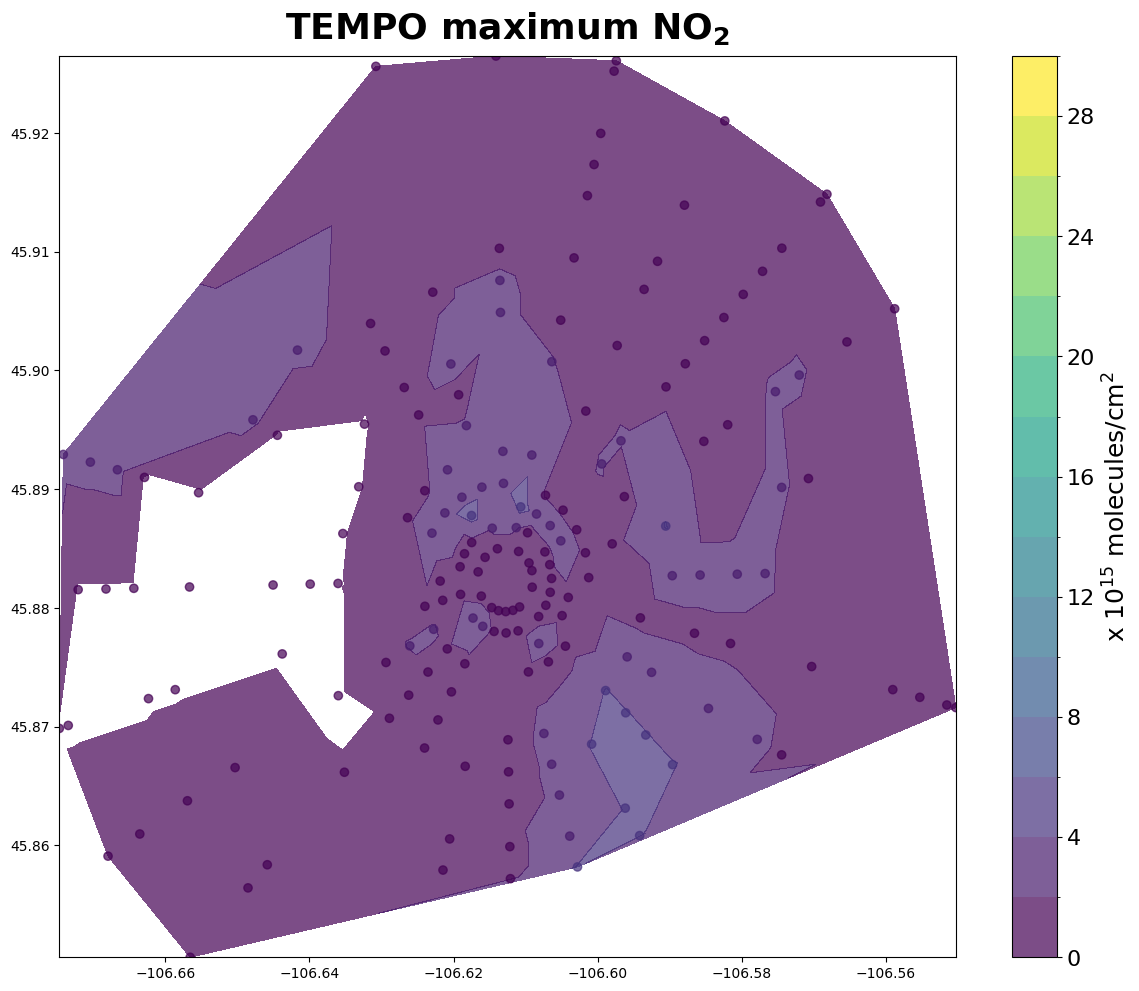

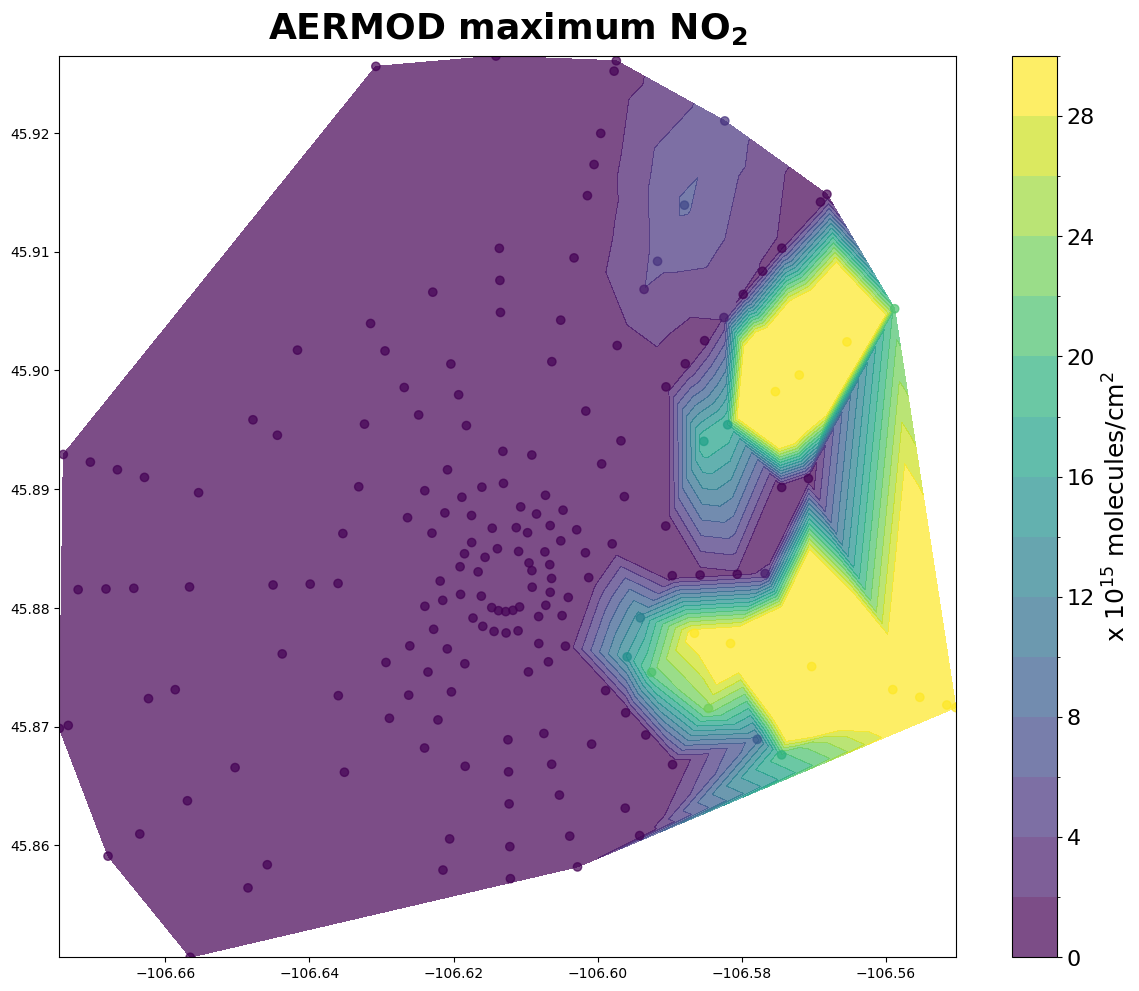

In [ ]:
#!/home/harkey/miniconda3/envs/plotenv/bin/python

import os
import glob
import gc
import pandas as pd
import numpy as np
from scipy.interpolate import CubicSpline
from metpy.interpolate import log_interpolate_1d
from metpy.units import units
import utm
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import matplotlib.colors as colors

# plot_AERMOD-TEMPO_col.py
# this script will read output from calc_AERMOD_col.py
# and will plot average or maximum values (specified by "plotthis" below)

# infileheader = '/data/harkey/TEMPO/Colstrip_2024/ColstripMT-NWS_AERMOD-TEMPO_2024'
months = ['01','02','03','04','05','06','07','08','09','10','11','12']
plotthis = 'maximum' # options are ['average','maximum']

AERMODplotname = 'ColstripMT-NWS_2024_AERMOD_'+plotthis+'NO2'
TEMPOplotname = 'ColstripMT-NWS_2024_TEMPO_'+plotthis+'NO2'

###############################################################################################################################

# read in files
#################################################################
# infiles = []
# for m in months:
#    infiles.append('/content/ColstripMT-NWS_AERMOD-TEMPO_202401.csv')
#    print(infiles[0])

# if (len(infiles)>1):
#    data = pd.concat((pd.read_csv(f) for f in infiles), ignore_index=True)
# else:
#    data = pd.read_csv(infiles[0])
#   #  print(data.head())

data = pd.read_csv('/content/ColstripMT-NWS_AERMOD-TEMPO_202401.csv')
# convert time column from object to datetime
print(data.head())



# get days (time column = date and hour)
data['day'] = pd.to_datetime(data['time']).dt.date



#################################################################
# get daily averages or daily maxima
if (plotthis=='average'):
   toplot = data.groupby(['receptor_lon','receptor_lat','day'])[['AERMOD_col','TEMPO_col']].mean().reset_index()
   bounds = [0,1,2,4,6,8,10,12,14,16,18,20,300]
elif (plotthis=='maximum'):
   toplot = data.groupby(['receptor_lon','receptor_lat','day'])[['AERMOD_col','TEMPO_col']].max().reset_index()
   #bounds = [0,5,10,15,25,50,100,120,150,200,300]
   bounds = [0,2,4,6,8,10,12,14,16,18,20,22,24,26,28,300]

# now average the averages or maxima
toplot = toplot.groupby(['receptor_lon','receptor_lat'])[['AERMOD_col','TEMPO_col']].mean().reset_index()
#print(toplot)
# get range of data, want to use the same range of values so each plot has same colorbar
maxval = max(max(toplot['TEMPO_col']),max(toplot['AERMOD_col']))
#bounds = np.arange(0,maxval)
#if (len(bounds) > 256): bounds = np.linspace(0,maxval,15,dtype=int)
norm = colors.BoundaryNorm(boundaries=bounds, ncolors=256)

# first plot TEMPO data
cmap = plt.get_cmap('viridis') #viridis works nicely
fig, ax = plt.subplots(figsize=(12, 10))
contour_plot = plt.tricontourf(toplot['receptor_lon'], toplot['receptor_lat'], toplot['TEMPO_col'], cmap = cmap, norm=norm, levels=bounds, alpha = 0.7)
plt.scatter(toplot['receptor_lon'],toplot['receptor_lat'],c=toplot['TEMPO_col'], cmap = cmap, norm=norm, alpha = 0.7)
fig = plt.gcf()
#ax.set_xticks([toplot['receptor_lon']])
#ax.set_yticks([toplot['receptor_lat']])
ax.grid(False) # tick marks set automatically, but don't want grid
fig.patch.set_facecolor('none')
# plt.yscale('log', base=10)
#plt.xlabel('longitude', fontsize=16)
#plt.ylabel('latitude', fontsize=16)
plt.title(r'TEMPO '+plotthis+' NO$\mathregular{_2}$', fontsize=26, fontweight='bold', y=1.01)
plt.legend(frameon=False)
# Remove white space
plt.tight_layout()
cbar = plt.colorbar()
cbar.set_label(label=r'x $\mathregular{10^{15}}$ molecules/cm$\mathregular{^2}$', size=18)
cbar.ax.tick_params(labelsize=16)
# plt.yticks(fontsize=14)
# plt.xticks(fontsize=14)
#plt.grid(True, which='both', axis='both')
plt.savefig(TEMPOplotname+'.png',format='png',dpi=300)
print('TEMPO data values range from ',min(toplot['TEMPO_col']),' - ',max(toplot['TEMPO_col']))

# now the AERMOD data
fig, ax = plt.subplots(figsize=(12, 10))
contour_plot = plt.tricontourf(toplot['receptor_lon'], toplot['receptor_lat'], toplot['AERMOD_col'], cmap = cmap, norm=norm, levels=bounds, alpha = 0.7)
plt.scatter(toplot['receptor_lon'],toplot['receptor_lat'],c=toplot['AERMOD_col'], cmap = cmap, norm=norm, alpha = 0.7)
fig = plt.gcf()
#ax.set_xticks([toplot['receptor_lon']])
#ax.set_yticks([toplot['receptor_lat']])
ax.grid(False) # tick marks set automatically, but don't want grid
fig.patch.set_facecolor('none')
# plt.yscale('log', base=10)
#plt.xlabel('longitude', fontsize=16)
#plt.ylabel('latitude', fontsize=16)
plt.title(r'AERMOD '+plotthis+' NO$\mathregular{_2}$', fontsize=26, fontweight='bold', y=1.01)
plt.legend(frameon=False)
# Remove white space
plt.tight_layout()
cbar = plt.colorbar()
cbar.set_label(label=r'x $\mathregular{10^{15}}$ molecules/cm$\mathregular{^2}$', size=18)
cbar.ax.tick_params(labelsize=16)
# plt.yticks(fontsize=14)
# plt.xticks(fontsize=14)
#plt.grid(True, which='both', axis='both')
plt.savefig(AERMODplotname+'.png',format='png',dpi=300)
print('AERMOD data values range from ',min(toplot['AERMOD_col']),' - ',max(toplot['AERMOD_col']))
